In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Reading Dataset

In [14]:
train = 'D:\ML_Project\Cup\ML-CUP24-TR.csv'
test = 'D:\ML_Project\Cup\ML-CUP24-TS.csv'

### Getting Input Datasets Ready

In [21]:
train_data = pd.read_csv(train, comment='#', header=None)
train_data = train_data.drop(train_data.columns[0], axis=1)

# Add column headers based on the format
columns = ['FEATURE1', 'FEATURE2', 'FEATURE3', 'FEATURE4', 'FEATURE5', 'FEATURE6', 
           'FEATURE7', 'FEATURE8', 'FEATURE9', 'FEATURE10', 'FEATURE11', 'FEATURE12',
           'TARGET_x', 'TARGET_y', 'TARGET_z']

train_data.columns = columns

print("Train shape: \n", train_data.shape)
print("Train: \n", train_data.head())

Train shape: 
 (250, 15)
Train: 
    FEATURE1  FEATURE2  FEATURE3  FEATURE4  FEATURE5  FEATURE6  FEATURE7  \
0  0.946373  0.307995  0.820058 -0.309386  0.950936 -0.000913 -0.093048   
1 -0.074075 -0.992654 -1.162582  0.997240 -0.074209 -0.002159 -0.004956   
2  0.841384  0.531605  0.810176 -0.534053  0.845451 -0.001057 -0.082832   
3  0.737117 -0.668400 -1.065601  0.671734  0.740793  0.000008  0.073704   
4 -0.987858 -0.119426 -1.072857  0.120013 -0.992772  0.000064 -0.098661   

   FEATURE8  FEATURE9  FEATURE10  FEATURE11  FEATURE12  TARGET_x  TARGET_y  \
0 -0.029318  0.995230  -1.175176   2.295016   0.223732 -0.011599 -0.503652   
1 -0.095561  0.995411   0.675930   3.147029  -0.297508 -0.361982 -0.186246   
2 -0.051079  0.995254  -1.069958   2.415989   0.234664  0.170027 -0.344143   
3 -0.066844  0.995038  11.038418   1.003455  -0.100332 -1.032355 -1.184874   
4 -0.011863  0.995050  14.834930   1.127759  -0.112600 -0.134817  2.047468   

    TARGET_z  
0  -5.564158  
1   3.445744  
2

In [22]:
test_data = pd.read_csv(test, comment='#', header=None)
test_data = test_data.drop(test_data.columns[0], axis=1)

# Add column headers based on the format
columns = ['FEATURE1', 'FEATURE2', 'FEATURE3', 'FEATURE4', 'FEATURE5', 'FEATURE6', 
           'FEATURE7', 'FEATURE8', 'FEATURE9', 'FEATURE10', 'FEATURE11', 'FEATURE12']

test_data.columns = columns

print("Test shape: \n", test_data.shape)
print("Test: \n", test_data.head())

Test shape: 
 (500, 12)
Test: 
    FEATURE1  FEATURE2  FEATURE3  FEATURE4  FEATURE5  FEATURE6  FEATURE7  \
0  0.964008  0.249750  0.621279 -0.251304  0.967891  0.005800 -0.086798   
1 -0.976968 -0.189726 -1.128659  0.190555 -0.981676  0.000850 -0.096032   
2  0.130254  0.986475  0.924671 -0.991395  0.130904  0.000001 -0.013024   
3 -0.153785  0.983480  0.744844 -0.988026 -0.154274 -0.002289  0.012480   
4 -0.655386 -0.749436 -1.182304  0.752975 -0.658039 -0.003522 -0.059142   

   FEATURE8  FEATURE9  FEATURE10  FEATURE11  FEATURE12  
0 -0.028503  0.995818  20.769237   4.786694   0.414053  
1 -0.017779  0.995219  19.189428   2.239992  -0.218716  
2 -0.098648  0.995037 -10.339886   1.000085   0.099999  
3 -0.094696  0.995428  -0.650716   3.219906   0.303438  
4 -0.073003  0.995577   0.490563   3.837265  -0.350978  


### Understanding Data

In [23]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   FEATURE1   250 non-null    float64
 1   FEATURE2   250 non-null    float64
 2   FEATURE3   250 non-null    float64
 3   FEATURE4   250 non-null    float64
 4   FEATURE5   250 non-null    float64
 5   FEATURE6   250 non-null    float64
 6   FEATURE7   250 non-null    float64
 7   FEATURE8   250 non-null    float64
 8   FEATURE9   250 non-null    float64
 9   FEATURE10  250 non-null    float64
 10  FEATURE11  250 non-null    float64
 11  FEATURE12  250 non-null    float64
 12  TARGET_x   250 non-null    float64
 13  TARGET_y   250 non-null    float64
 14  TARGET_z   250 non-null    float64
dtypes: float64(15)
memory usage: 29.4 KB


#### Target Distribution 

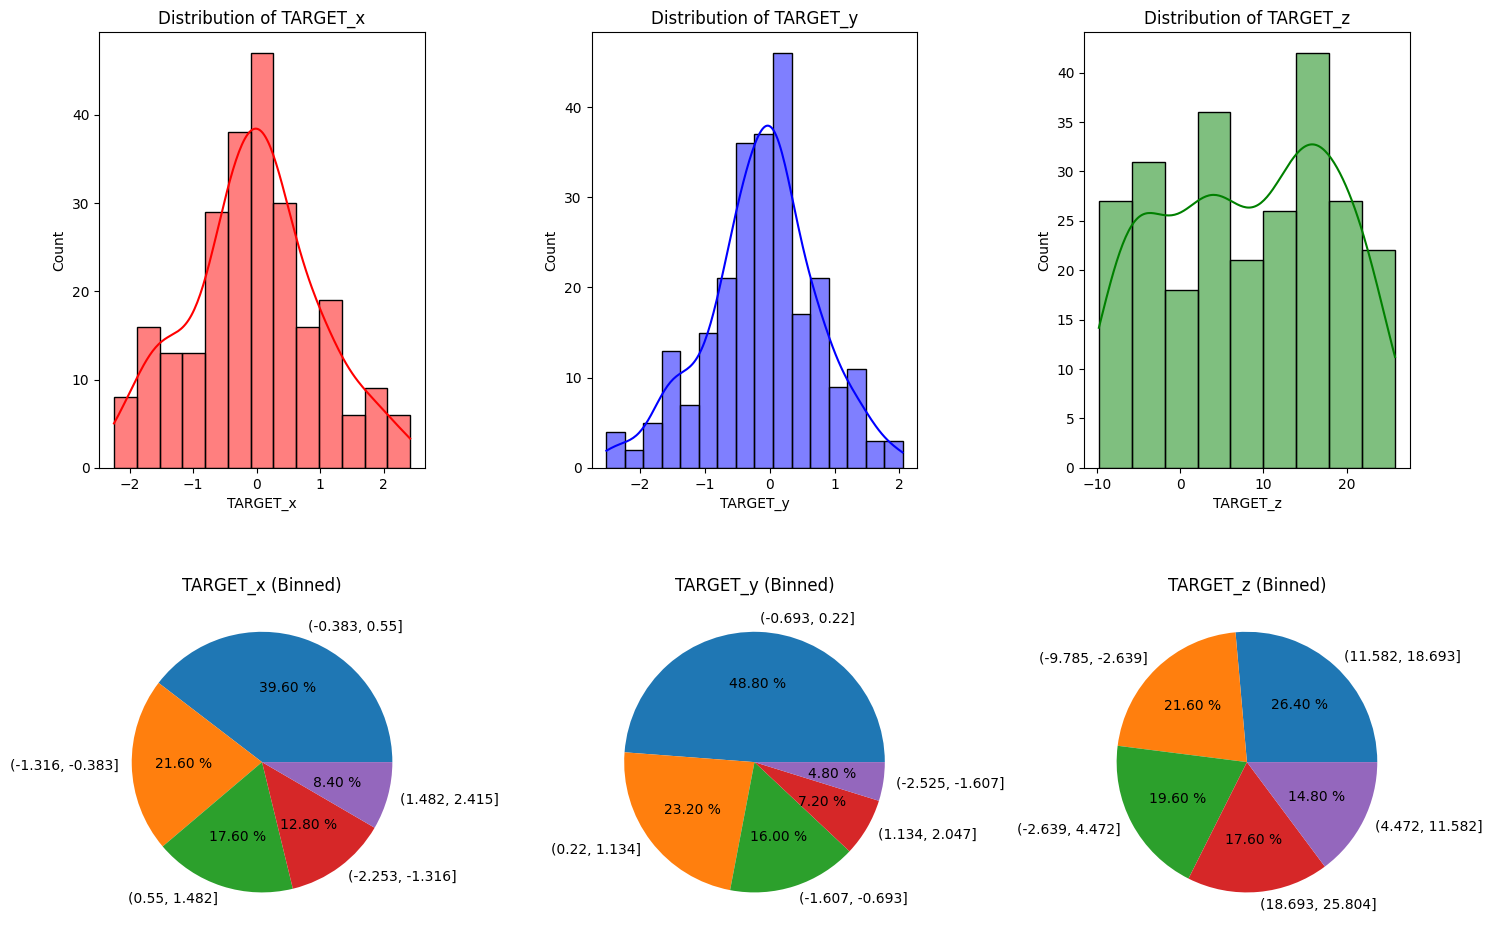

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# (CUP) TARGET_x: Histogram and KDE
sns.histplot(train_data['TARGET_x'], kde=True, ax=axs[0, 0], color='red')
axs[0, 0].set_title('Distribution of TARGET_x')

# Pie chart for TARGET_x - only if categorical or discrete
# Group values into bins for better visualization in pie chart
bins_x = pd.cut(train_data['TARGET_x'], bins=5)
pie_data_x = bins_x.value_counts()
axs[1, 0].pie(pie_data_x.values, labels=pie_data_x.index, autopct='%.2f %%')
axs[1, 0].set_title('TARGET_x (Binned)')

# (CUP) TARGET_y: Histogram and KDE
sns.histplot(train_data['TARGET_y'], kde=True, ax=axs[0, 1], color='blue')
axs[0, 1].set_title('Distribution of TARGET_y')

# Pie chart for TARGET_y
bins_y = pd.cut(train_data['TARGET_y'], bins=5)
pie_data_y = bins_y.value_counts()
axs[1, 1].pie(pie_data_y.values, labels=pie_data_y.index, autopct='%.2f %%')
axs[1, 1].set_title('TARGET_y (Binned)')

# (CUP) TARGET_z: Histogram and KDE
sns.histplot(train_data['TARGET_z'], kde=True, ax=axs[0, 2], color='green')
axs[0, 2].set_title('Distribution of TARGET_z')

# Pie chart for TARGET_z
bins_z = pd.cut(train_data['TARGET_z'], bins=5)
pie_data_z = bins_z.value_counts()
axs[1, 2].pie(pie_data_z.values, labels=pie_data_z.index, autopct='%.2f %%')
axs[1, 2].set_title('TARGET_z (Binned)')

plt.tight_layout()
plt.show()

### Feature's Value Distribution

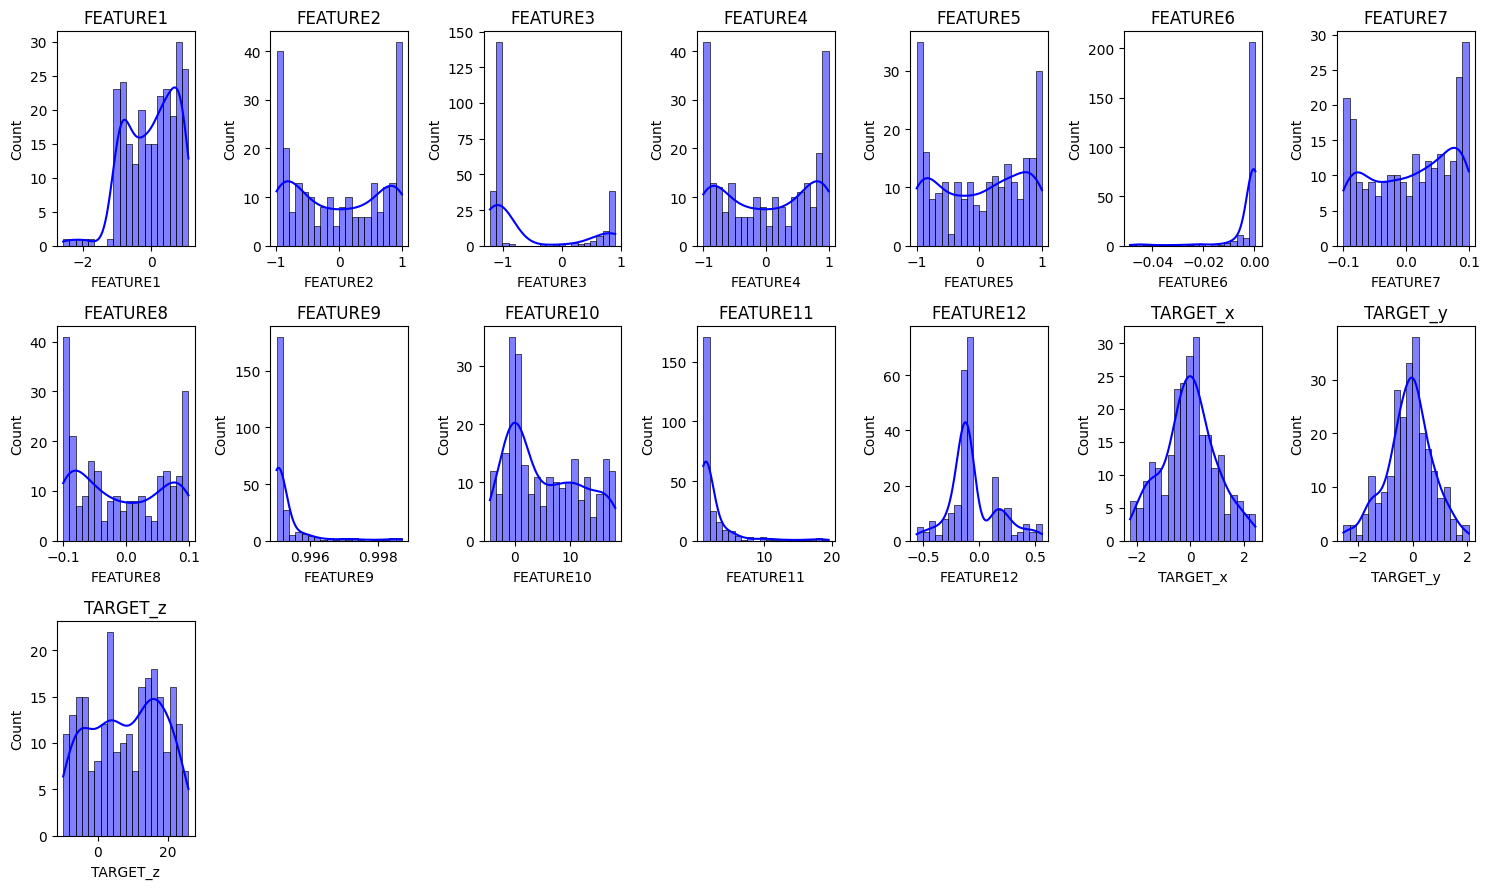

In [33]:
numerical_features = train_data.select_dtypes(exclude=['object'])
# Create subplots: Adjust rows and columns based on the number of numerical features
num_features = len(numerical_features.columns)
rows = (num_features // 7) + 1  # 7 plots per row
cols = min(num_features, 7)
fig, axs = plt.subplots(rows, cols, figsize=(15, 3 * rows))  # Dynamically adjust the figure size
axs = axs.flatten()  # Flatten to simplify indexing

# Function to show histograms for numerical features
def showHistogram(data):
    for i, feature in enumerate(data.columns):
        sns.histplot(data[feature], kde=True, ax=axs[i], color='blue', bins=20)  # Histogram with KDE
        axs[i].set_title(f'{feature}')
    # Hide unused axes if any
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

# Call the function
showHistogram(numerical_features)

plt.tight_layout()
plt.show()

### Correlation

Correlation Matrix:
           FEATURE1  FEATURE2  FEATURE3  FEATURE4  FEATURE5  FEATURE6  \
FEATURE1   1.000000 -0.011828 -0.148749  0.011879  0.932658  0.015414   
FEATURE2  -0.011828  1.000000  0.091252 -1.000000 -0.004727 -0.033425   
FEATURE3  -0.148749  0.091252  1.000000 -0.091470 -0.126487 -0.038584   
FEATURE4   0.011879 -1.000000 -0.091470  1.000000  0.004757  0.033338   
FEATURE5   0.932658 -0.004727 -0.126487  0.004757  1.000000 -0.006944   
FEATURE6   0.015414 -0.033425 -0.038584  0.033338 -0.006944  1.000000   
FEATURE7   0.424131 -0.018641  0.060488  0.018437  0.490362  0.047398   
FEATURE8   0.037536  0.468922 -0.031948 -0.469067  0.037887 -0.193866   
FEATURE9  -0.061208  0.029705  0.074321 -0.029630 -0.042832 -0.986465   
FEATURE10  0.207886 -0.057262 -0.622929  0.057280  0.213220  0.290037   
FEATURE11 -0.041757  0.030534  0.086810 -0.030454 -0.020372 -0.986700   
FEATURE12 -0.121765 -0.000041  0.820902 -0.000519 -0.074812 -0.038047   
TARGET_x  -0.031989  0.762328  

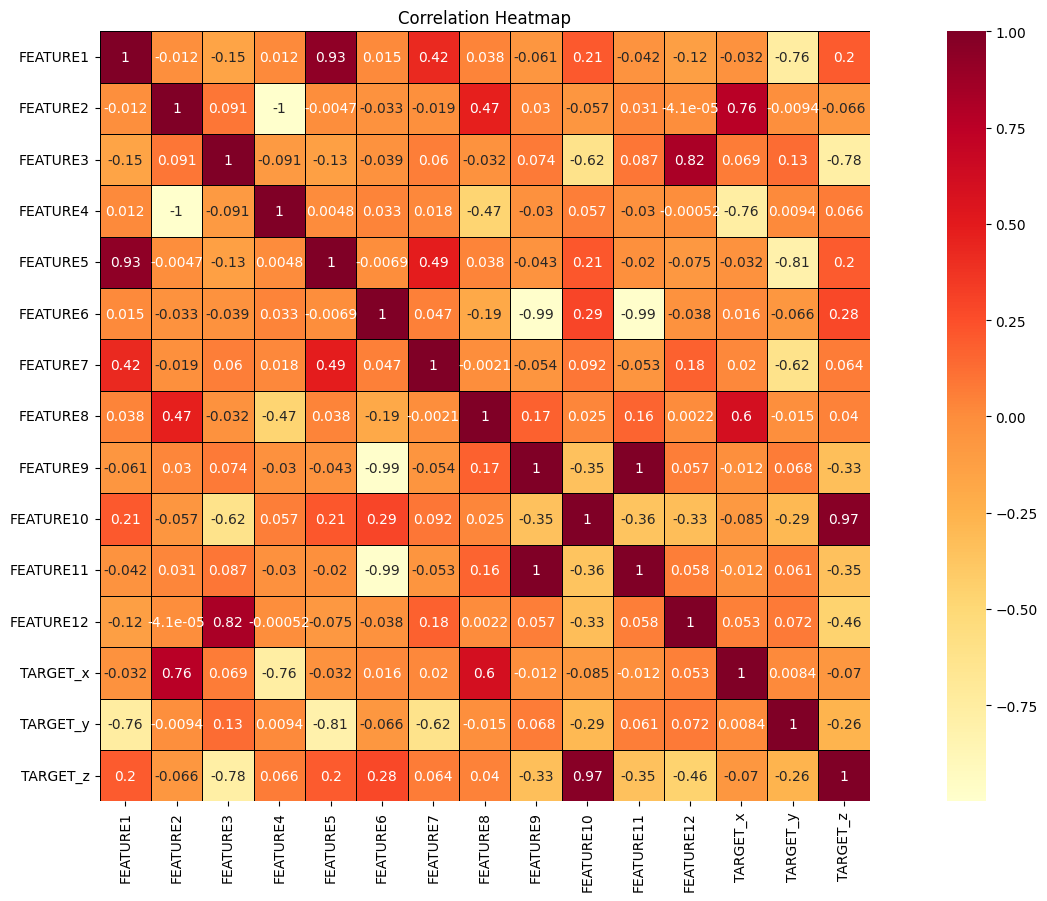


Correlations with TARGET_x:
TARGET_x     1.000000
FEATURE2     0.762328
FEATURE8     0.604753
FEATURE3     0.068646
FEATURE12    0.052742
FEATURE7     0.020189
FEATURE6     0.015845
TARGET_y     0.008352
FEATURE9    -0.011676
FEATURE11   -0.011717
FEATURE1    -0.031989
FEATURE5    -0.032366
TARGET_z    -0.069726
FEATURE10   -0.084591
FEATURE4    -0.762593
Name: TARGET_x, dtype: float64

Correlations with TARGET_y:
TARGET_y     1.000000
FEATURE3     0.127498
FEATURE12    0.071744
FEATURE9     0.068077
FEATURE11    0.061461
FEATURE4     0.009430
TARGET_x     0.008352
FEATURE2    -0.009436
FEATURE8    -0.014913
FEATURE6    -0.066241
TARGET_z    -0.259155
FEATURE10   -0.289129
FEATURE7    -0.624759
FEATURE1    -0.755810
FEATURE5    -0.811631
Name: TARGET_y, dtype: float64

Correlations with TARGET_z:
TARGET_z     1.000000
FEATURE10    0.968430
FEATURE6     0.276069
FEATURE1     0.202586
FEATURE5     0.200713
FEATURE4     0.066437
FEATURE7     0.063696
FEATURE8     0.039597
FEATURE2    -0.

In [37]:
targets=['TARGET_x', 'TARGET_y', 'TARGET_z']

# Select only numerical features
numerical_data = train_data.select_dtypes(exclude=['object'])
# Calculate correlation matrix
corr_matrix = numerical_data.corr(method='pearson')
print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, square=True, cmap="YlOrRd", linecolor="black")
plt.title('Correlation Heatmap')
plt.show()

# Display and return correlations for each target
for target in targets:
    if target in corr_matrix.columns:
        print(f"\nCorrelations with {target}:")
        corr_res = corr_matrix[target].sort_values(ascending=False)
        print(corr_res)
    else:
        print(f"\nWarning: {target} not found in correlation matrix.")